In [1]:
import os
import sys
import tqdm
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.summary import get_model_stats

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet34

import warnings
warnings.filterwarnings('ignore')

In [2]:
from data.voc import get_voc_pipeline_test

train_loader, val_loader, test_loader = get_voc_pipeline_test(batch_size=8)
sample_x, sample_y = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)   # oh so it squeezes it for me... interesting change...

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
torch.Size([8, 3, 256, 256])
torch.Size([8, 256, 256])


In [3]:
import torch
import torch.nn as nn
from torchvision.models import resnet34

class UNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super(UNet, self).__init__()
        # Load a pretrained ResNet encoder
        self.encoder = resnet34(pretrained=pretrained)
        self.base_layers = list(self.encoder.children())

        # Encoder layers
        self.enc1 = nn.Sequential(*self.base_layers[:3])  # Conv1 + BN + ReLU
        self.enc2 = nn.Sequential(*self.base_layers[3:5])  # MaxPool + Layer1
        self.enc3 = self.base_layers[5]  # Layer2
        self.enc4 = self.base_layers[6]  # Layer3
        self.enc5 = self.base_layers[7]  # Layer4

        # Decoder with extra upsampling to restore original size
        self.up4 = self._upsample_block(512, 256)
        self.up3 = self._upsample_block(256, 128)
        self.up2 = self._upsample_block(128, 64)
        self.up1 = self._upsample_block(64, 64)
        self.up_final = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1)

        # Final output layer
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def _upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Decoder with skip connections
        d4 = self.up4(e5) + e4
        d3 = self.up3(d4) + e3
        d2 = self.up2(d3) + e2
        d1 = self.up1(d2) + e1
        
        # Final upsampling to restore original size
        d_final = self.up_final(d1)

        # Final output
        out = self.final_conv(d_final)
        return out

In [4]:
# Example usage
model = UNet(num_classes=21, pretrained=True)  # Adjust num_classes for your task
output = model(sample_x)
print("Output shape:", output.shape)
get_model_stats(model, sample_x.shape)

Output shape: torch.Size([8, 21, 256, 256])


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::add encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.avgpool, encoder.fc


{'flops': 49073881088, 'params': 24233149}

In [5]:
import torch
import torch.nn as nn

class MIoU(nn.Module):
    def __init__(self, num_classes=21, ignore_index=255):
        super(MIoU, self).__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()
        
    def reset(self):
        self.intersection = torch.zeros(self.num_classes)
        self.union = torch.zeros(self.num_classes)
        
    def forward(self, outputs, targets):
        """
        Args:
            outputs: [B, C, H, W] tensor of raw model outputs (logits)
            targets: [B, H, W] tensor of ground truth labels
        Returns:
            mean IoU score (scalar)
        """
        # Convert logits to predictions
        preds = torch.argmax(outputs, dim=1)  # [B, H, W]
        
        batch_size = outputs.size(0)
        mean_iou = 0.0
        
        for b in range(batch_size):
            current_pred = preds[b]  # [H, W]
            current_target = targets[b]  # [H, W]
            
            # Create mask for valid pixels (not ignore_index)
            valid_mask = current_target != self.ignore_index
            
            # Calculate per-class IoU
            class_iou_sum = 0.0
            valid_classes = 0
            
            for cls in range(self.num_classes):
                pred_mask = (current_pred == cls) & valid_mask
                target_mask = (current_target == cls) & valid_mask
                
                intersection = torch.logical_and(pred_mask, target_mask).sum().item()
                union = torch.logical_or(pred_mask, target_mask).sum().item()
                
                # Only count classes that appear in the ground truth
                if union > 0:
                    class_iou_sum += intersection / union
                    valid_classes += 1
            
            # Average IoU across valid classes for this image
            if valid_classes > 0:
                mean_iou += class_iou_sum / valid_classes
        
        # Average across batch
        return torch.tensor(mean_iou / batch_size) if batch_size > 0 else torch.tensor(0.0)
    
    # Added for compatibility with previous evaluation function
    def compute(self):
        # For this implementation compute() is not needed since forward() calculates directly
        # But we keep it for interface compatibility
        return self.intersection.sum() / self.union.sum() if self.union.sum() > 0 else 0.0
    
    # Added for compatibility with previous training loop
    def update(self, outputs, targets):
        # Calculate batch IoU and accumulate stats
        with torch.no_grad():
            preds = torch.argmax(outputs, dim=1)
            
            for cls in range(self.num_classes):
                valid_mask = targets != self.ignore_index
                pred_mask = (preds == cls) & valid_mask
                target_mask = (targets == cls) & valid_mask
                
                intersection = torch.logical_and(pred_mask, target_mask).sum().item()
                union = torch.logical_or(pred_mask, target_mask).sum().item()
                
                self.intersection[cls] += intersection
                self.union[cls] += union
                

def evaluate_model(val_loader: DataLoader, model: nn.Module, criterion: nn.Module, device: str='cpu') -> list:
    """
    Evaluate the model on validation data.

    Args:
        model: The PyTorch model to evaluate.
        val_loader: DataLoader for the validation data.
        criterion: Loss function.
        device: Device to run the evaluation on ('cpu' or 'cuda').

    Returns:
        list: Collection of metrics.
    """
    model.eval()
    epoch_metrics = []
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            inputs = inputs.to(device)
            targets = targets.to(device)
            preds = model(inputs)
            loss = criterion(preds, targets)
            epoch_metrics.append(loss.item())
    return epoch_metrics

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
val_criterion = MIoU()
train_criterion = nn.CrossEntropyLoss(ignore_index=255)

model = model.to(device)
val_loss = evaluate_model(val_loader, model, val_criterion, device)
val_loss = evaluate_model(val_loader, model, train_criterion, device)

evaluating...: 100%|██████████| 182/182 [00:15<00:00, 12.13it/s]


# Teacher 

In [10]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)  # Ensure predictions are in range [0,1] for binary segmentation
        targets = targets.float()  # Convert to float
        
        intersection = torch.sum(preds * targets)
        union = torch.sum(preds) + torch.sum(targets)
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice  # Dice Loss to be minimized

evaluating...: 100%|██████████| 182/182 [00:27<00:00,  6.54it/s]
Epoch 1: New best accuracy: 0.3130 saving model...
evaluating...: 100%|██████████| 182/182 [00:25<00:00,  7.19it/s]
Epoch 3: New best accuracy: 0.3173 saving model...
evaluating...: 100%|██████████| 182/182 [00:26<00:00,  6.87it/s]
Epoch 13: Early stop triggered.


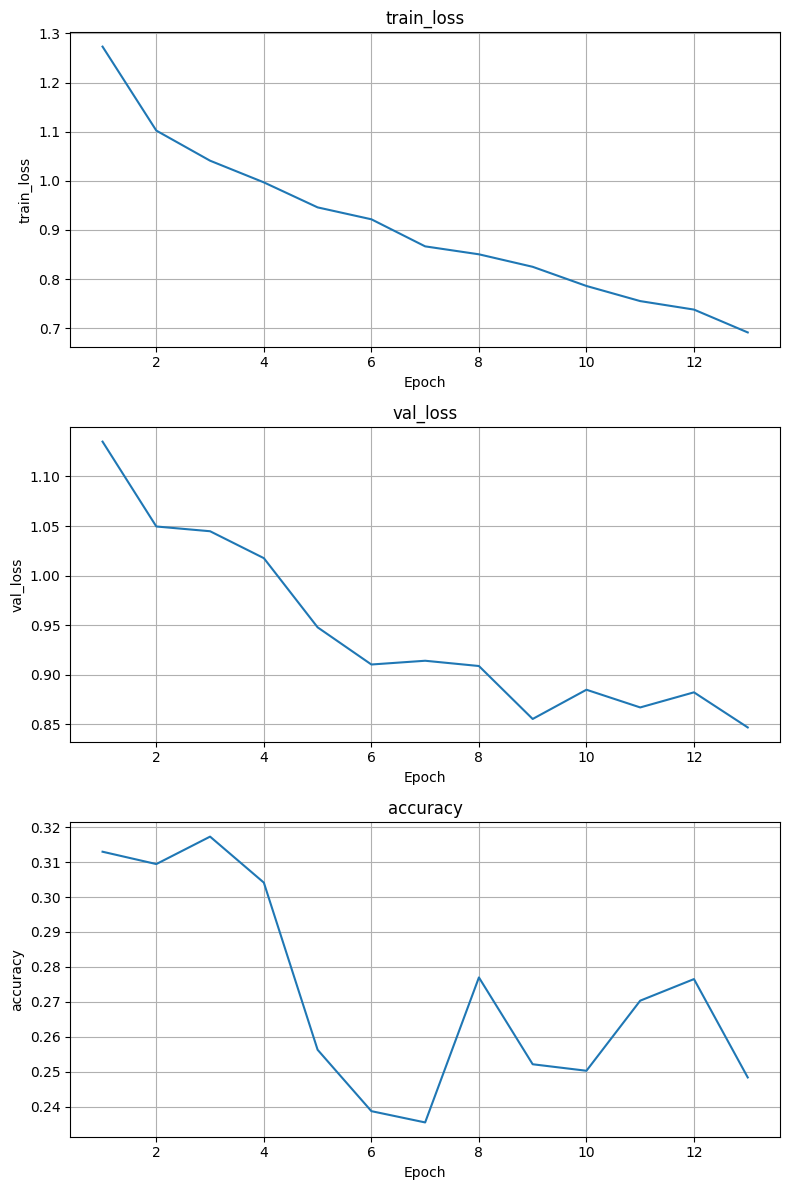

In [13]:
from utils.pipeline import train_val
from utils.plots import plot_training_metrics

model = UNet(num_classes=21, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=255)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

aux_metrics = {'accuracy': MIoU()}
path = '../models/weights/unet_teacher.pth'

metrics = train_val(train_loader, val_loader, model, criterion, optimizer, scheduler, device, aux_metrics, path, patience=20)
plot_training_metrics(metrics)

# Distill

In [ ]:
def distillation_loss(student_logits, teacher_logits, labels, T=2.0, alpha=0.5):
    """
    Compute the knowledge distillation loss.
    
    Args:
        student_logits: Logits from the student model
        teacher_logits: Logits from the teacher model
        labels: True labels
        T: Temperature for softening probability distributions
        alpha: Weight for the distillation loss vs. standard cross-entropy loss
    
    Returns:
        Combined loss
    """
    soft_targets = F.softmax(teacher_logits / T, dim=1)
    soft_prob = F.log_softmax(student_logits / T, dim=1)
    distillation = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T * T)
    standard_loss = F.cross_entropy(student_logits, labels)
    return alpha * distillation + (1 - alpha) * standard_loss


def train_with_distillation(student_model, teacher_model, train_loader, optimizer, device, alpha=0.5, temperature=2.0):
    student_model.train()
    teacher_model.eval()  # Teacher is fixed during distillation
    
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.squeeze(1).long().to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with student
        student_output = student_model(data)
        
        # Get teacher predictions (no grad needed)
        with torch.no_grad():
            teacher_output = teacher_model(data)
        
        # Calculate distillation loss
        loss = distillation_loss(
            student_output, 
            teacher_output, 
            target, 
            T=temperature,
            alpha=alpha, 
        )
        
        # Backward and optimize
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


In [ ]:
from models.unet import TeacherUNet
from models.unet import StudentUNet

# criterion = nn.CrossEntropyLoss(ignore_index=255)
teacher = TeacherUNet(in_channels=3, num_classes=21).to(device)
student = StudentUNet(in_channels=3, num_classes=21).to(device)
teacher.load_state_dict(torch.load('../models/weights/teacher_seg.pth', map_location=device)['state_dict'])
criterion = MIoU(20)
# optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
optimizer = torch.optim.Adam(student.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
student_path = f'../models/weights/student_seg.pth'

metrics = {'train_loss': [], 'MIoU': []}

for epoch in range(100):
    train_loss = train_with_distillation(
        student, 
        teacher, 
        train_loader, 
        optimizer, 
        device,
        alpha=0.5, 
        temperature=2.0
    )
    val_loss = evaluate_model(val_loader, student, criterion, device)
    metrics['train_loss'].append(np.mean(train_loss))
    metrics['MIoU'].append(np.mean(val_loss))